# Binary Logistic Regression on a Loan Dataset
We're assuming that the dataset has been cleaned already using the `DataAcqCleaning.ipynb` notebook.

In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import exp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import scale
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from dotenv import load_dotenv
import os

In [4]:
load_dotenv()
clean_loan_dataset_path = os.getenv('clean_dataset_path')
df = pd.read_csv(clean_loan_dataset_path)
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,False,False,True,False,False,False,True,False
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,False,True,False,True,False,False,False,False
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,False,False,False,False,False,True,False,False
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,False,False,True,False,False,True,False,False
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,False,False,True,False,False,True,False,False
5,21.0,1,0,12951.0,0,2500.0,7.14,0.19,2.0,532,0,1,False,True,False,False,False,False,False,True
6,26.0,1,2,93471.0,1,35000.0,12.42,0.37,3.0,701,0,1,False,False,True,True,False,False,False,False
7,24.0,1,0,95550.0,5,35000.0,11.11,0.37,4.0,585,0,1,False,False,True,False,False,True,False,False
8,24.0,1,1,100684.0,3,35000.0,8.90,0.35,2.0,544,0,1,False,False,True,False,False,False,True,False
9,21.0,1,0,12739.0,0,1600.0,14.74,0.13,3.0,640,0,1,False,True,False,False,False,False,False,True


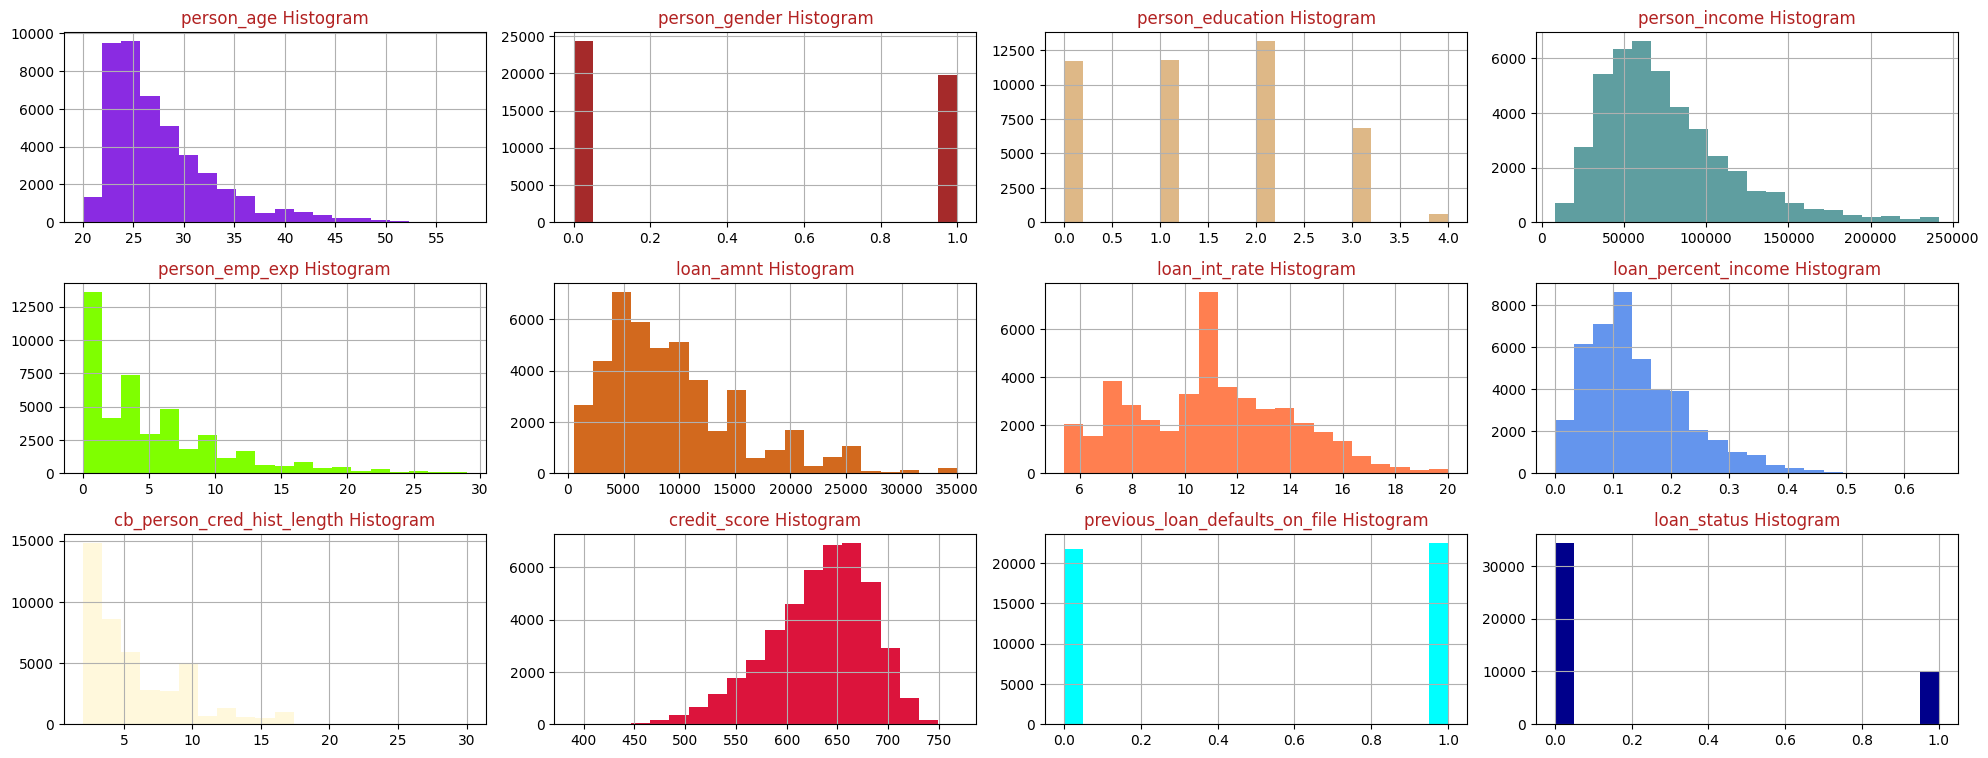

In [5]:
import matplotlib.colors as mcolors
num_cols = df.select_dtypes(include=["number"]).columns

colors = list(mcolors.CSS4_COLORS.keys())[10:]
fig = plt.figure(figsize=(20,20))
for i, feature in enumerate(num_cols):
    f = fig.add_subplot(8, 4, i + 1)
    df[feature].hist(bins = 20, ax = f, facecolor = colors[i])
    f.set_title(feature + " Histogram", color = colors[35])
fig.tight_layout()
plt.show()

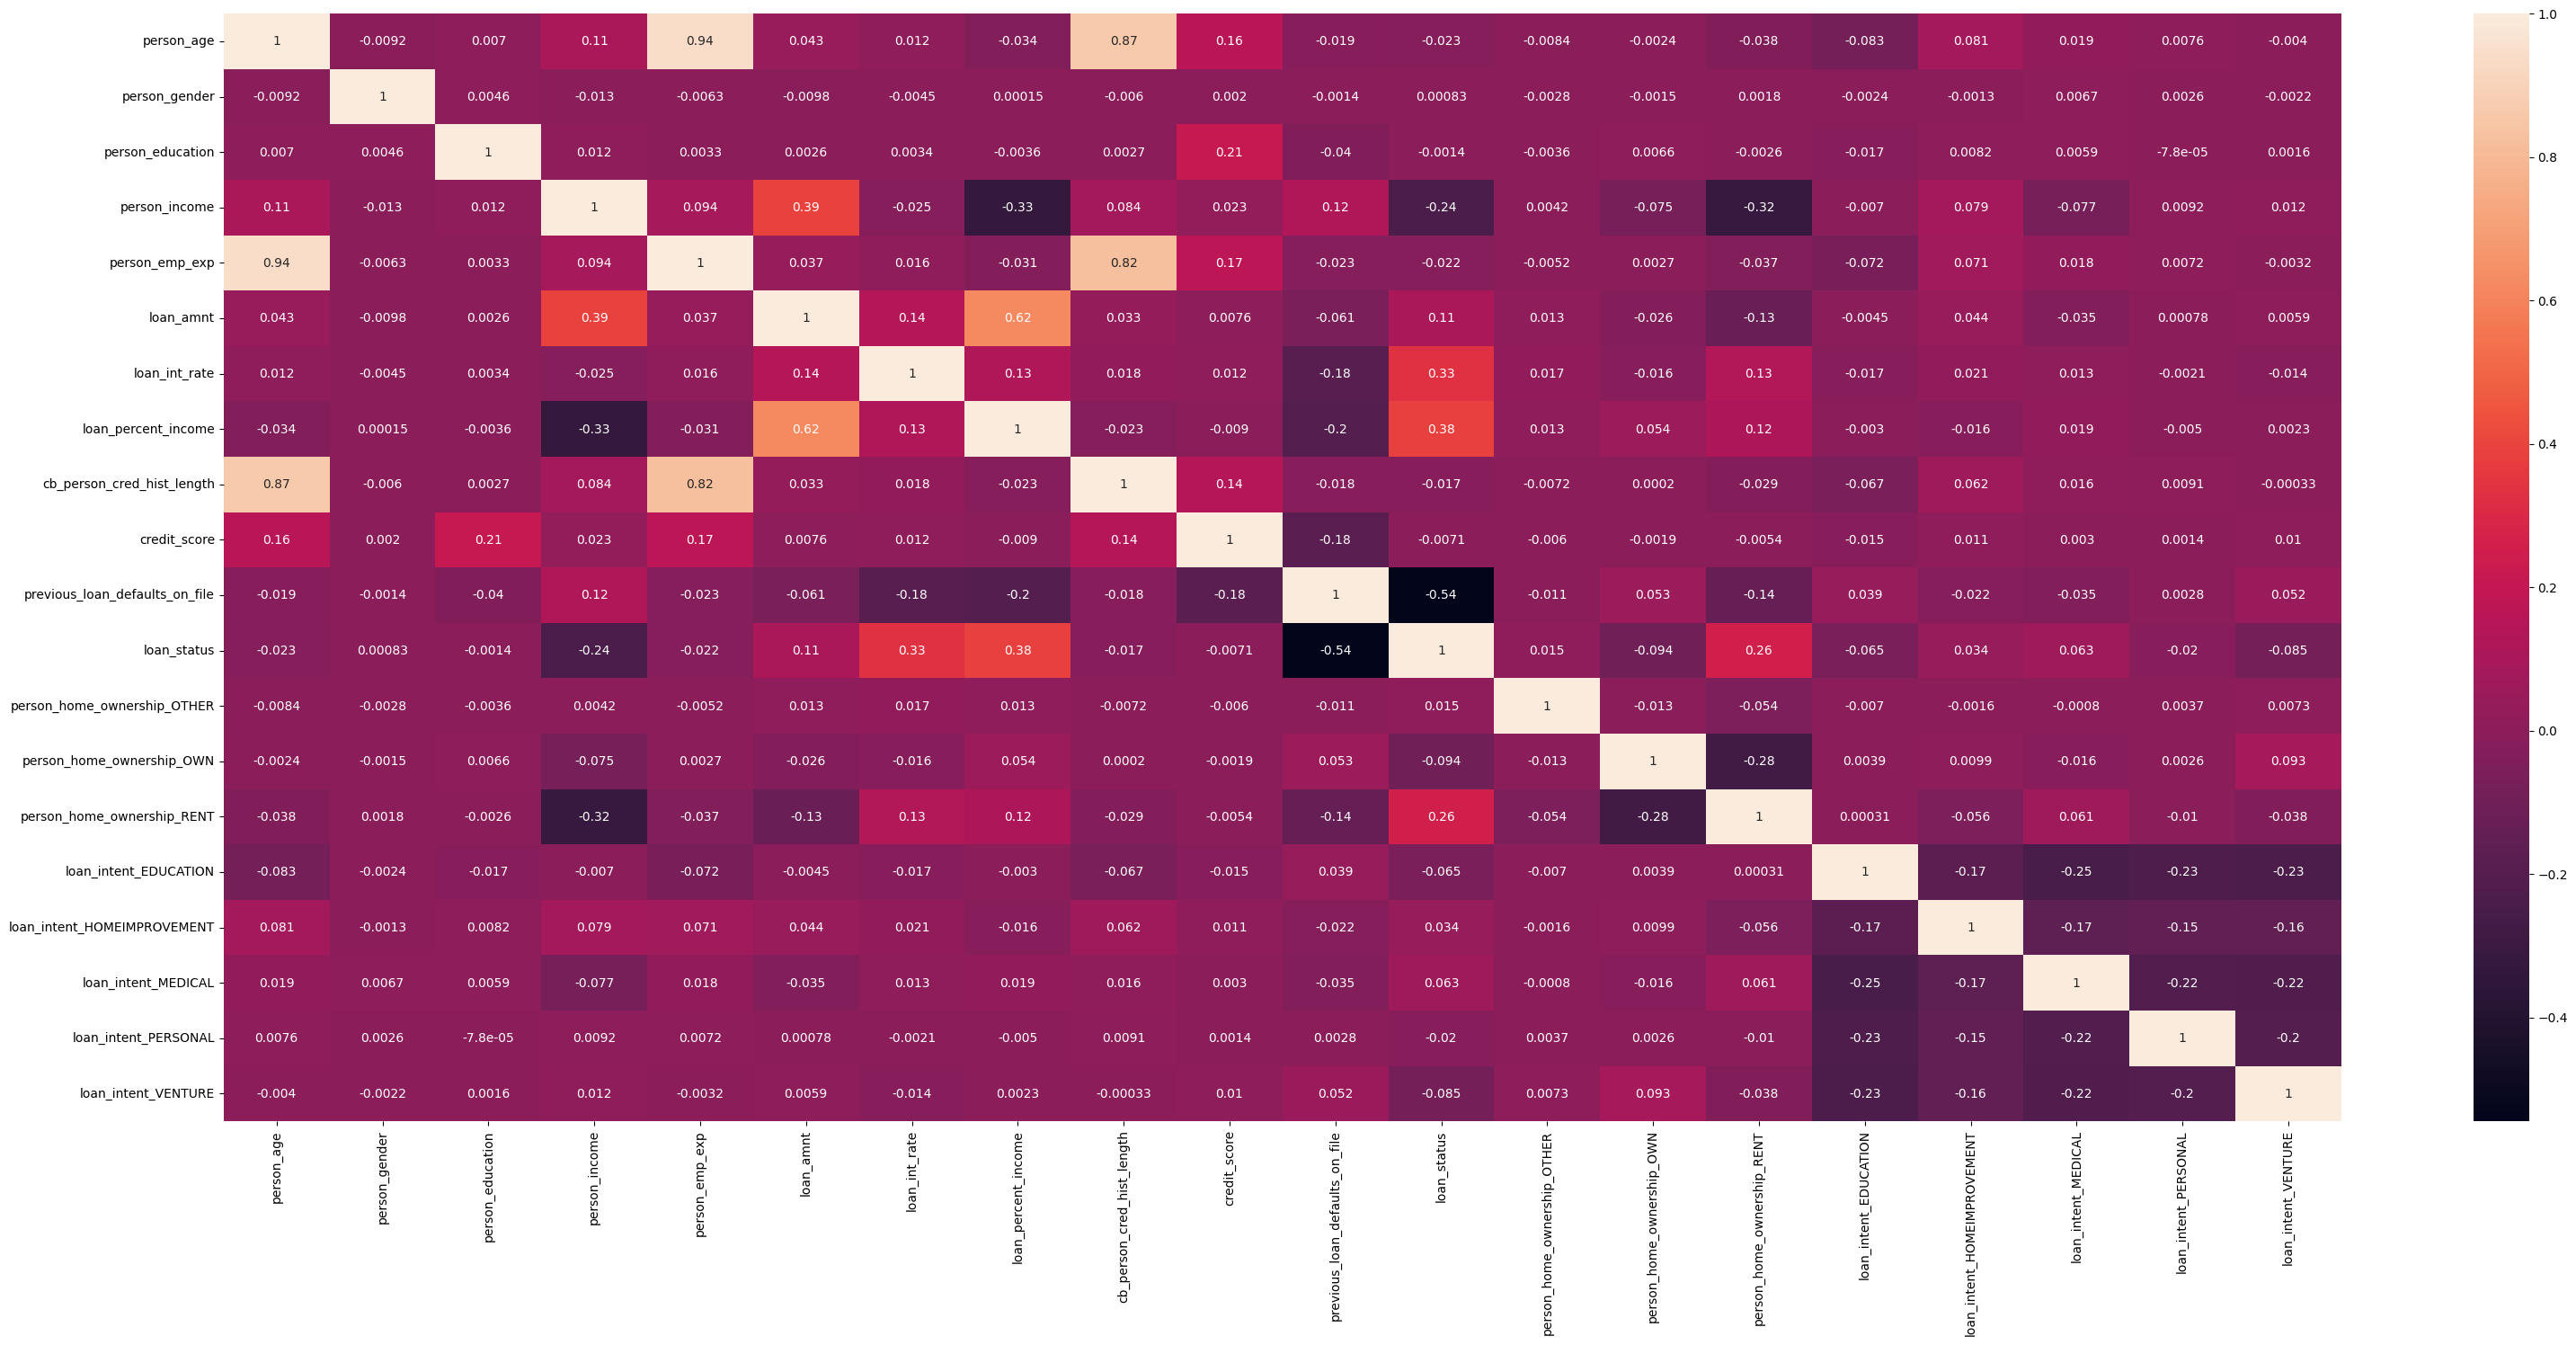

In [6]:
plt.figure(figsize = (38, 16))
sns.heatmap(df.corr(), annot = True)
plt.show()

## Building the model and training

In [7]:
y = df.loan_status;
X = df.iloc[:, df.columns != 'loan_status']
print(f"There are {y.sum():,} cases of accepted loans out of {len(df):,} total cases.")
print(f"Proportion of accepted cases: {y.mean():.2%}")

There are 9,858 cases of accepted loans out of 44,136 total cases.
Proportion of accepted cases: 22.34%


In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12, stratify=y)

# Scale the data
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

In [9]:
model = LogisticRegression();
model.fit(X_train_scaled, y_train)
train_accuracy = model.score(X_train_scaled, y_train)
print(f'The accuracy for the training set is {100 * train_accuracy:.2f}%')
test_accuracy = model.score(X_test_scaled, y_test)
print(f'The accuracy for the test set is {100 * test_accuracy:.2f}%')

The accuracy for the training set is 89.70%
The accuracy for the test set is 90.09%
